# 静态场景 - 密度扫描实验
固定业务比例，扫描不同总密度下的性能表现

## 初始化环境

In [1]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（使用新的分离函数）
from utils.evaluate import (
    static_sensitivity_config,
    train_scenario,
    evaluate_scenario_ppo,
    evaluate_scenario_baseline,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 密度扫描配置生成

In [3]:
def run_density_sweep_experiment():
    """
    密度扫描实验：固定业务比例，扫描总密度
    用于绘制：Throughput vs. Density 曲线
    """
    # 1. 定义几个固定的业务混合模式
    traffic_mixes = {
        "CBRA_Heavy": {'cbra': 0.7, 'pbra': 0.2, 'cfra': 0.1},
    }

    # 2. 定义要扫描的密度范围
    densities = [5.0, 10.0, 25.0, 40.0]
    configs = []

    print("--- Generating Density Sweep Configs ---")
    for mix_name, ratios in traffic_mixes.items():
        for d in densities:
            cfg = static_sensitivity_config(
                total_density=d,
                cbra_ratio=ratios['cbra'],
                pbra_ratio=ratios['pbra'],
                cfra_ratio=ratios['cfra']
            )
            label = f"{mix_name}_D{int(d)}"
            configs.append((label, cfg))
            print(f"Generated: [{label}]")

    return configs

# 生成配置
density_sweep_configs = run_density_sweep_experiment()
print(f"\n总共生成 {len(density_sweep_configs)} 个密度扫描场景配置")

--- Generating Density Sweep Configs ---
Generated: [CBRA_Heavy_D5]
Generated: [CBRA_Heavy_D10]
Generated: [CBRA_Heavy_D25]
Generated: [CBRA_Heavy_D40]

总共生成 4 个密度扫描场景配置


## 加载训练配置

In [4]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_density_sweep_CBRA.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f"Warning: Could not remove existing log file: {e}")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for density sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=10,
    decision_horizon=100,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=3200,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=10,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(density_sweep_configs)} 个场景待训练")


2025-12-04 11:20:55 | INFO     | Logger initialized for density sweep experiment


Loaded configuration from conf\default.yaml
配置加载完成: 4 个场景待训练


2025-12-04 11:20:55 | INFO     | Config ready | seed=42 num_envs=8


## 执行密度扫描训练

In [5]:
# 全局结果存储
all_train_results = OrderedDict()  # 存储训练结果

print(f"\n{'='*80}")
print(f"开始批量训练 {len(density_sweep_configs)} 个密度扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(density_sweep_configs):
    print(f"\n[{idx+1}/{len(density_sweep_configs)}] 当前场景: {label}")
    try:
        # 训练模型
        train_result = train_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            seed=seed
        )

        all_train_results[label] = train_result
        print(f"✓ 场景 {label} 训练完成")

    except Exception as e:
        print(f"✗ 场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_train_results)}/{len(density_sweep_configs)}")
print(f"{'='*80}")



开始批量训练 4 个密度扫描场景


[1/4] 当前场景: CBRA_Heavy_D5

开始训练场景: CBRA_Heavy_D5
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.7_P0.2_F0.1', cbra_density=3.5, pbra_density=1.0, cfra_density=0.5),), segments=(RegionSegment(region_name='static_D5.0_C0.7_P0.2_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-04 11:20:55,972 [torchrl][INFO]    The info_dict_reader does not have specs. The o

2025-12-04 11:20:55,993 [torchrl][INFO]    check_env_specs succeeded! [END]


e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-04 11:20:59 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D5


  iter=0000, reward=0.2944
训练完成: 最佳奖励=0.4847 (迭代9)
✓ 场景 CBRA_Heavy_D5 训练完成

[2/4] 当前场景: CBRA_Heavy_D10

开始训练场景: CBRA_Heavy_D10
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D10.0_C0.7_P0.2_F0.1', cbra_density=7.0, pbra_density=2.0, cfra_density=1.0),), segments=(RegionSegment(region_name='static_D10.0_C0.7_P0.2_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-04 11:21:24,884 [torch

2025-12-04 11:21:27 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D10


  iter=0000, reward=-0.8811
训练完成: 最佳奖励=0.5391 (迭代9)
✓ 场景 CBRA_Heavy_D10 训练完成

[3/4] 当前场景: CBRA_Heavy_D25

开始训练场景: CBRA_Heavy_D25
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D25.0_C0.7_P0.2_F0.1', cbra_density=17.5, pbra_density=5.0, cfra_density=2.5),), segments=(RegionSegment(region_name='static_D25.0_C0.7_P0.2_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-04 11:21:53,219 [to

2025-12-04 11:21:56 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D25


  iter=0000, reward=-3.3956
训练完成: 最佳奖励=-0.2796 (迭代9)
✓ 场景 CBRA_Heavy_D25 训练完成

[4/4] 当前场景: CBRA_Heavy_D40

开始训练场景: CBRA_Heavy_D40
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D40.0_C0.7_P0.2_F0.1', cbra_density=28.0, pbra_density=8.0, cfra_density=4.0),), segments=(RegionSegment(region_name='static_D40.0_C0.7_P0.2_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-04 11:22:21,560 [t

2025-12-04 11:22:24 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D40


  iter=0000, reward=-2.9610
训练完成: 最佳奖励=-0.4846 (迭代8)
✓ 场景 CBRA_Heavy_D40 训练完成

所有场景训练完成!
成功训练场景数: 4/4
训练完成: 最佳奖励=-0.4846 (迭代8)
✓ 场景 CBRA_Heavy_D40 训练完成

所有场景训练完成!
成功训练场景数: 4/4


## 可视化密度扫描结果

In [6]:
# 评估所有训练好的模型
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始评估 {len(all_train_results)} 个训练好的场景")
print(f"{'='*80}\n")

for idx, (label, train_result) in enumerate(all_train_results.items()):
    print(f"\n[{idx+1}/{len(all_train_results)}] 评估场景: {label}")
    try:
        # 第一步：评估PPO模型（best和last）
        ppo_eval_result = evaluate_scenario_ppo(
            scenario_name=label,
            scenario_env_config=train_result['env_config'],
            actor=train_result['actor'],
            critic=train_result['critic'],
            rl_env=train_result['rl_env'],
            best_model=train_result['best_model'],
            last_model=train_result['last_model'],
            num_episodes=20,
            seed=seed
        )

        # 第二步：评估baseline策略
        baseline_eval_result = evaluate_scenario_baseline(
            scenario_name=label,
            scenario_env_config=train_result['env_config'],
            run_episode_func=run_episode,
            num_episodes=20,
            seed=seed
        )

        # 合并结果
        result = {
            'train_rewards': [m['reward'] for m in train_result['metrics_history']],
            'eval_results_best': ppo_eval_result['eval_results_best'],
            'eval_results_last': ppo_eval_result['eval_results_last'],
            'baseline_results': baseline_eval_result['baseline_results']
        }

        all_scenarios_results[label] = result
        print(f"✓ 场景 {label} 评估完成")

    except Exception as e:
        print(f"✗ 场景 {label} 评估失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景评估完成!")
print(f"成功评估场景数: {len(all_scenarios_results)}/{len(all_train_results)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)



开始评估 4 个训练好的场景


[1/4] 评估场景: CBRA_Heavy_D5

评估场景 CBRA_Heavy_D5 的PPO模型...
  评估最佳模型...
  评估最后一轮模型...
  评估最后一轮模型...
  PPO最佳奖励: 50.7873
  PPO最后奖励: 49.2362

评估场景 CBRA_Heavy_D5 的Baseline策略...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.7_P0.2_F0.1', cbra_density=3.5, pbra_density=1.0, cfra_density=0.5),), segments=(RegionSegment(region_name='static_D5.0_C0.7_P0.2_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten

## 评估训练好的模型

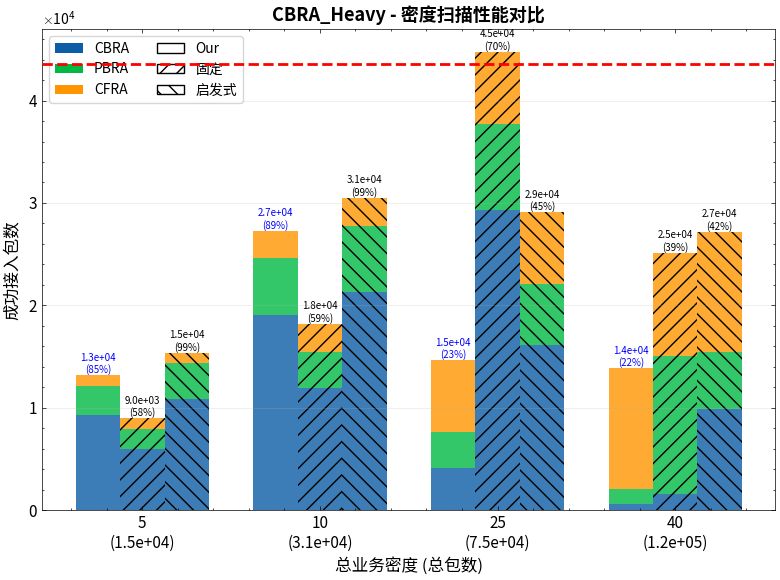

密度扫描对比图已保存到: output/static/density_sweep_CBRA.svg


In [ ]:
def plot_density_sweep_results():
    """绘制密度扫描实验结果 - 单个流量模式的图"""
    traffic_mixes = ["CBRA_Heavy"]
    densities = [5.0, 10.0, 25.0, 40.0]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    for mix_idx, mix_name in enumerate(traffic_mixes):
        # 收集数据
        ppo_cbra = []
        ppo_pbra = []
        ppo_cfra = []
        ppo_theo = []
        fixed_cbra = []
        fixed_pbra = []
        fixed_cfra = []
        fixed_theo = []
        heuristic_cbra = []
        heuristic_pbra = []
        heuristic_cfra = []
        heuristic_theo = []
        total_arrivals_list = []

        for d in densities:
            label = f"{mix_name}_D{int(d)}"
            if label in all_scenarios_results:
                result = all_scenarios_results[label]

                # PPO最佳模型
                ppo_cbra.append(result['eval_results_last']['eval_success_cbra'])
                ppo_pbra.append(result['eval_results_last']['eval_success_pbra'])
                ppo_cfra.append(result['eval_results_last']['eval_success_cfra'])
                ppo_theo.append(result['eval_results_last'].get('eval_theoretical_optimal', 0))

                # 固定分配
                fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
                fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
                fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])
                fixed_theo.append(result['baseline_results']['固定分配'].get('theoretical_optimal', 0))

                # 启发式算法
                heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
                heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
                heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
                heuristic_theo.append(result['baseline_results']['启发式算法'].get('theoretical_optimal', 0))

                # 获取总到达包数 (使用固定分配的到达数作为参考)
                total_arr = (result['baseline_results']['固定分配']['arrivals_cbra'] +
                           result['baseline_results']['固定分配']['arrivals_pbra'] +
                           result['baseline_results']['固定分配']['arrivals_cfra'])
                total_arrivals_list.append(total_arr)
            else:
                ppo_cbra.append(0)
                ppo_pbra.append(0)
                ppo_cfra.append(0)
                ppo_theo.append(0)
                fixed_cbra.append(0)
                fixed_pbra.append(0)
                fixed_cfra.append(0)
                fixed_theo.append(0)
                heuristic_cbra.append(0)
                heuristic_pbra.append(0)
                heuristic_cfra.append(0)
                heuristic_theo.append(0)
                total_arrivals_list.append(0)

        ppo_cbra = np.array(ppo_cbra)
        ppo_pbra = np.array(ppo_pbra)
        ppo_cfra = np.array(ppo_cfra)
        ppo_theo = np.array(ppo_theo)
        fixed_cbra = np.array(fixed_cbra)
        fixed_pbra = np.array(fixed_pbra)
        fixed_cfra = np.array(fixed_cfra)
        fixed_theo = np.array(fixed_theo)
        heuristic_cbra = np.array(heuristic_cbra)
        heuristic_pbra = np.array(heuristic_pbra)
        heuristic_cfra = np.array(heuristic_cfra)
        heuristic_theo = np.array(heuristic_theo)

        ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
        fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
        heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

        # 绘制堆叠柱状图
        x = np.arange(len(densities))
        width = 0.25

        # Our (最佳) - 实心
        p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
        p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
        p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

        # 固定分配 - 斜线填充
        p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
        p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
        p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

        # 启发式算法 - 反斜线填充
        p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
        p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
        p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

        # 添加理论最优值水平线 (使用平均值)
        # avg_theo = np.mean([t for t in ppo_theo if t > 0])
        # if avg_theo > 0:
        #     ax.axhline(avg_theo, color='red', linestyle='--', linewidth=2,
        #               label=f'理论最优 (平均={int(avg_theo)})', zorder=10)

        # 标注总数和达最优率
        for i in range(len(densities)):
            if ppo_total[i] > 0:
                theo_rate = (ppo_total[i] / ppo_theo[i] * 100) if ppo_theo[i] > 0 else 0
                ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7, color='blue')
            if fixed_total[i] > 0:
                theo_rate = (fixed_total[i] / fixed_theo[i] * 100) if fixed_theo[i] > 0 else 0
                ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)
            if heuristic_total[i] > 0:
                theo_rate = (heuristic_total[i] / heuristic_theo[i] * 100) if heuristic_theo[i] > 0 else 0
                ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('总业务密度 (总包数)', fontsize=12)
        ax.set_ylabel('成功接入包数', fontsize=12)
        ax.set_title(f'{mix_name} - 密度扫描性能对比', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        # 横轴标签添加总包数信息
        xticklabels = [f'{int(d)}\n({int(arr):.1e})' if arr > 0 else f'{int(d)}'
                      for d, arr in zip(densities, total_arrivals_list)]
        ax.set_xticklabels(xticklabels, fontsize=10)

        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='C0', label='CBRA'),
            Patch(facecolor='C1', label='PBRA'),
            Patch(facecolor='C2', label='CFRA'),
            Patch(facecolor='white', edgecolor='black', label='Our'),
            Patch(facecolor='white', edgecolor='black', hatch='//', label='固定'),
            Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式'),
        ]
        ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

        ax.tick_params(labelsize=11)
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs("output/static", exist_ok=True)
    plt.savefig("output/static/density_sweep_CBRA.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("密度扫描对比图已保存到: output/static/density_sweep_CBRA.svg")

# 绘制结果
plot_density_sweep_results()
